In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving yellow_tripdata_2024-01.parquet to yellow_tripdata_2024-01 (1).parquet


In [ ]:
import pandas as pd

filename = list(uploaded.keys())[0]
df = pd.read_parquet(filename)

df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [ ]:
import numpy as np

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Trip duration in minutes
df['trip_duration_min'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Keep only valid trips
df = df[
    (df['trip_distance'] > 0) &
    (df['trip_duration_min'] > 0) &
    df['PULocationID'].notna() &
    df['DOLocationID'].notna()
]

df[['trip_distance', 'trip_duration_min', 'PULocationID', 'DOLocationID']].head()


,trip_distance,trip_duration_min,PULocationID,DOLocationID
0,1.72,19.800000,186,79
1,1.80,6.600000,140,236
2,4.70,17.916667,236,79
3,1.40,8.300000,79,211
4,0.80,6.100000,211,148


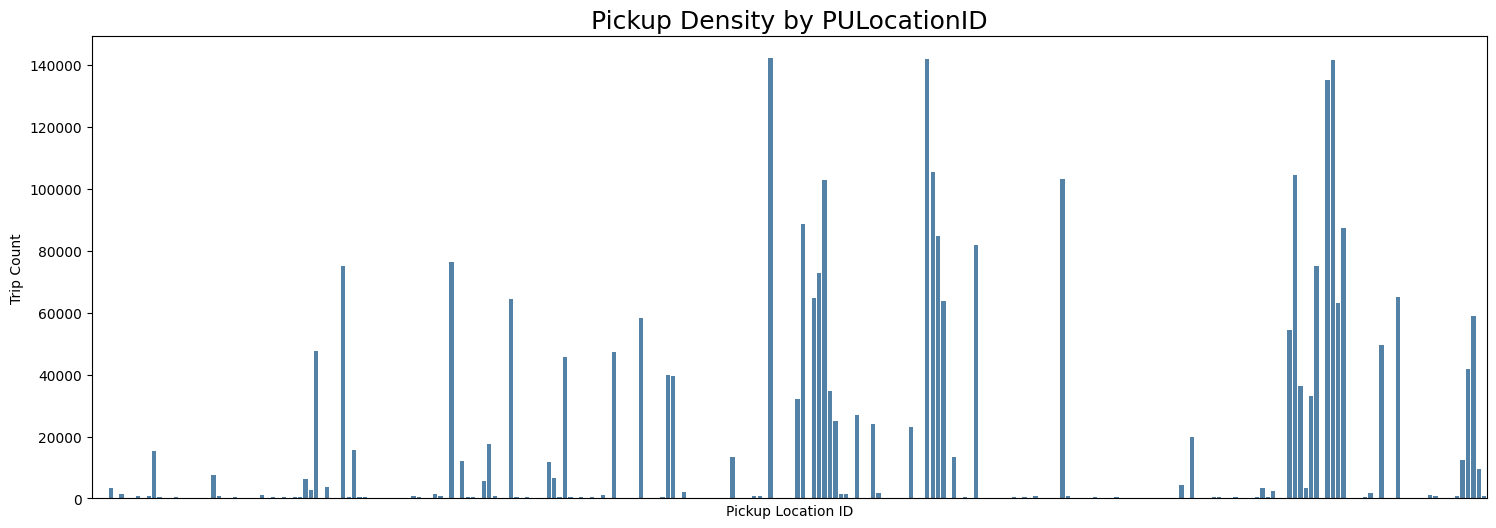

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pickup_counts = df['PULocationID'].value_counts().sort_index()

plt.figure(figsize=(18,6))
sns.barplot(x=pickup_counts.index, y=pickup_counts.values, color='steelblue')
plt.title("Pickup Density by PULocationID", fontsize=18)
plt.xlabel("Pickup Location ID")
plt.ylabel("Trip Count")
plt.xticks([], [])
plt.show()


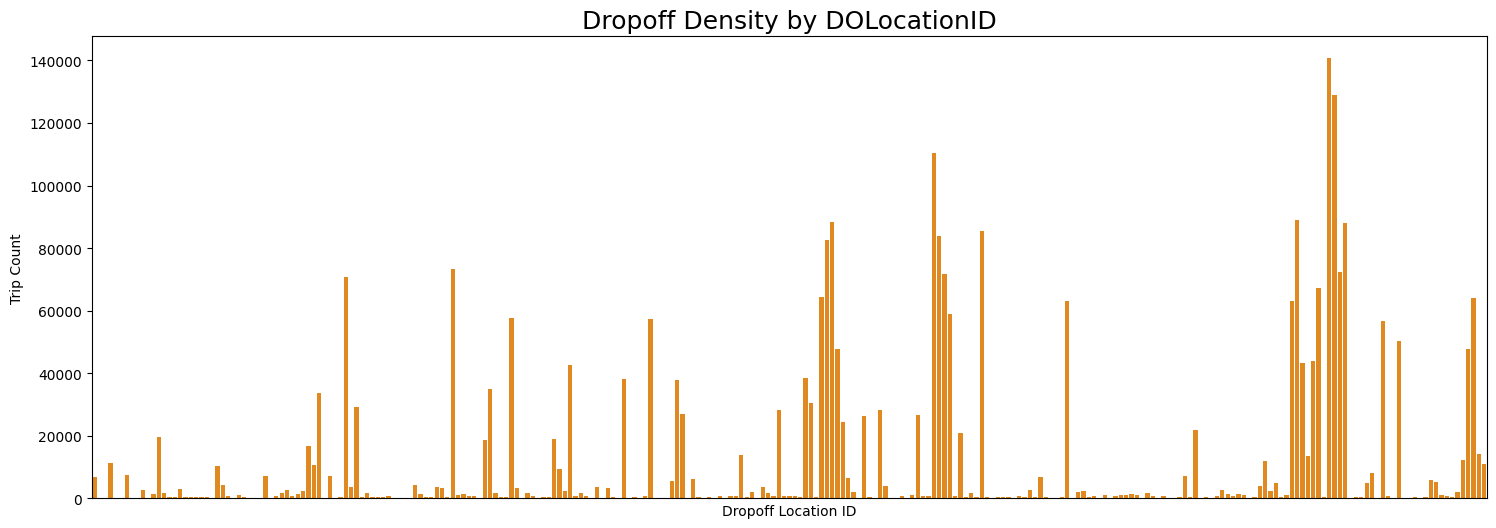

In [ ]:
dropoff_counts = df['DOLocationID'].value_counts().sort_index()

plt.figure(figsize=(18,6))
sns.barplot(x=dropoff_counts.index, y=dropoff_counts.values, color='darkorange')
plt.title("Dropoff Density by DOLocationID", fontsize=18)
plt.xlabel("Dropoff Location ID")
plt.ylabel("Trip Count")
plt.xticks([], [])
plt.show()


In [ ]:
od = df.groupby(['PULocationID', 'DOLocationID']).size().reset_index(name='count')

# Sort by count
top_od = od.sort_values('count', ascending=False).head(20)

top_od


,PULocationID,DOLocationID,count
22529,237,236,21816
22318,236,237,19331
22317,236,236,15461
22530,237,237,14406
15069,161,237,10244
13075,142,239,8924
22467,237,161,8799
15068,161,236,8727
22828,239,142,8623
22901,239,238,8383


In [ ]:
od = df.groupby(['PULocationID', 'DOLocationID']).size().reset_index(name='count')

# Create the pivot table for the heatmap
pivot = od.pivot_table(
    index='PULocationID',
    columns='DOLocationID',
    values='count',
    fill_value=0
)


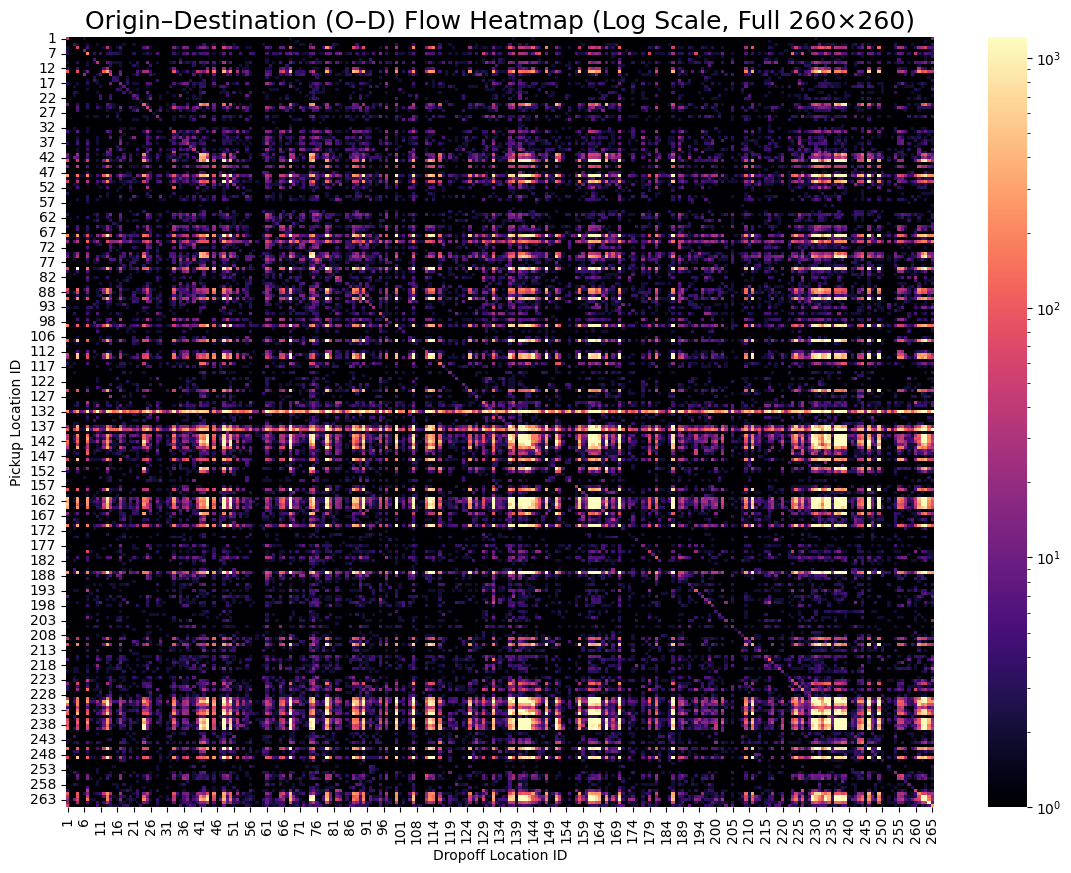

In [ ]:
import numpy as np
from matplotlib.colors import LogNorm



pivot_plus = pivot + 1


vmax = np.percentile(pivot_plus.values, 99)

plt.figure(figsize=(14, 10))
sns.heatmap(
    pivot_plus,
    cmap="magma",
    norm=LogNorm(vmax=vmax),
    cbar=True
)
plt.title("Origin–Destination (O–D) Flow Heatmap (Log Scale, Full 260×260)", fontsize=18)
plt.xlabel("Dropoff Location ID")
plt.ylabel("Pickup Location ID")
plt.show()


In [ ]:
zone_features = df.groupby('PULocationID').agg({
    'fare_amount':'mean',
    'trip_distance':'mean',
    'trip_duration_min':'mean',
    'tip_amount':'mean',
    'PULocationID':'count'
}).rename(columns={'PULocationID':'trip_count'})

zone_features['tip_percentage'] = zone_features['tip_amount'] / zone_features['fare_amount']

zone_features = zone_features.drop(columns=['tip_amount'])

zone_features.head()


,fare_amount,trip_distance,trip_duration_min,trip_count,tip_percentage
PULocationID,,,,,
1,74.883962,6.032453,7.928616,53,0.130506
2,48.616667,12.756667,24.383333,3,0.122043
3,41.920244,9.670000,42.755488,82,0.005955
4,16.217674,32.328076,15.628272,3306,0.154410
6,24.420000,3.852105,27.957895,19,0.083215


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(zone_features)


In [ ]:
# Replace any NaN values with the column mean
zone_features_clean = zone_features.fillna(zone_features.mean())

X_scaled = scaler.fit_transform(zone_features_clean)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
zone_features_clean['cluster'] = kmeans.fit_predict(X_scaled)

zone_features_clean.head()



,fare_amount,trip_distance,trip_duration_min,trip_count,tip_percentage,cluster
PULocationID,,,,,,
1,74.883962,6.032453,7.928616,53,0.130506,2
2,48.616667,12.756667,24.383333,3,0.122043,2
3,41.920244,9.670000,42.755488,82,0.005955,2
4,16.217674,32.328076,15.628272,3306,0.154410,0
6,24.420000,3.852105,27.957895,19,0.083215,2


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Rebuild zone_features from df
zone_features = df.groupby('PULocationID').agg({
    'fare_amount': 'mean',
    'trip_distance': 'mean',
    'trip_duration_min': 'mean',
    'tip_amount': 'mean',
    'PULocationID': 'count'
}).rename(columns={'PULocationID': 'trip_count'})

zone_features['tip_percentage'] = zone_features['tip_amount'] / zone_features['fare_amount']
zone_features = zone_features.drop(columns=['tip_amount'])

zone_features_clean = zone_features.copy()
zone_features_clean = zone_features_clean.fillna(zone_features_clean.mean(numeric_only=True))

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(zone_features_clean)

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
zone_features_clean['cluster'] = kmeans.fit_predict(X_scaled)

zone_features_clean.head()


,fare_amount,trip_distance,trip_duration_min,trip_count,tip_percentage,cluster
PULocationID,,,,,,
1,74.883962,6.032453,7.928616,53,0.130506,2
2,48.616667,12.756667,24.383333,3,0.122043,2
3,41.920244,9.670000,42.755488,82,0.005955,2
4,16.217674,32.328076,15.628272,3306,0.154410,0
6,24.420000,3.852105,27.957895,19,0.083215,2


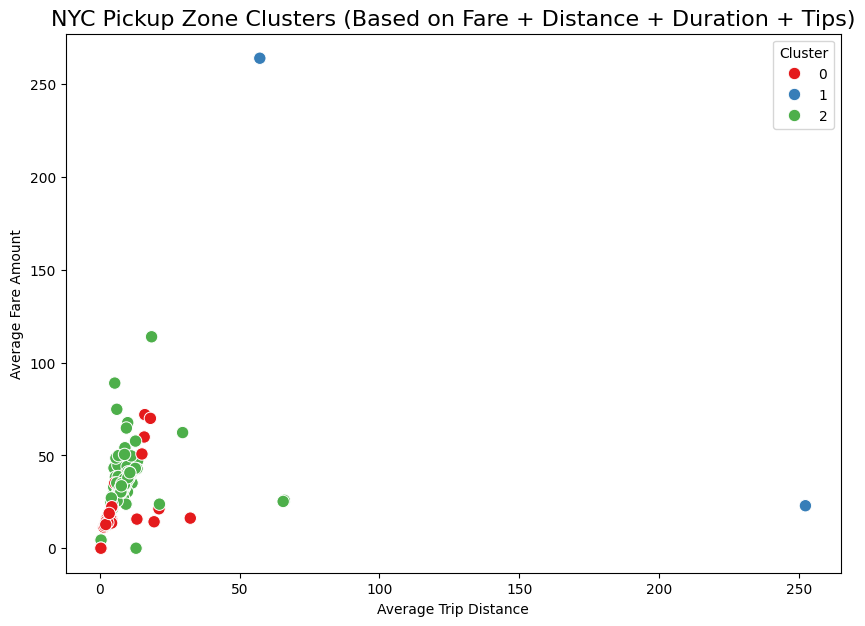

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=zone_features_clean,
    x='trip_distance',
    y='fare_amount',
    hue='cluster',
    palette='Set1',
    s=80
)

plt.title("NYC Pickup Zone Clusters (Based on Fare + Distance + Duration + Tips)", fontsize=16)
plt.xlabel("Average Trip Distance")
plt.ylabel("Average Fare Amount")
plt.legend(title="Cluster")
plt.show()


In [ ]:
df = df.loc[:, ~df.columns.duplicated()]
df = df.drop(columns=['pickup_cluster'], errors='ignore')


In [ ]:
df = df.merge(
    zone_features_clean[['cluster']],
    how='left',
    left_on='PULocationID',
    right_index=True
)

df.rename(columns={'cluster': 'pickup_cluster'}, inplace=True)

df[['PULocationID', 'pickup_cluster']].head()


,PULocationID,pickup_cluster
0,186,0
1,140,0
2,236,0
3,79,0
4,211,0


In [ ]:
df['pickup_cluster'].value_counts()


,count
pickup_cluster,
0,2849196
2,54613
1,332


In [ ]:
zone_features_clean[['cluster']].value_counts()


,count
cluster,
2,185
0,71
1,2


In [ ]:
df.to_parquet("cleaned_geo_df.parquet")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')